# Detekcja krawędzi

## Cel ćwiczenia

- Zapoznanie z metodami detekcji krawędzi:
    - Sobel, Prewitt, Roberts - przypomnienie,
    - Laplasjan z Gaussa (LoG – ang. Laplacian of Gaussian),
    - Canny.

Detekcja krawędzi przez wiele lat była podstawą algorytmów segmentacji.
Krawędzie wykrywane są najczęściej z wykorzystaniem pierwszej (gradient) i drugiej (Laplasjan) pochodnej przestrzennej.
Wykorzystanie obu metod zaprezentowane zostało w ćwiczeniu *Przetwarzanie wstępne. Filtracja kontekstowa*.

W niniejszym ćwiczeniu poznane detektory krawędzi zostaną porównane z bardziej zaawansowanymi: Laplasjan z funkcji Gaussa (LoG), Zero Crossing i Canny.

## Laplasjan z Gaussa (LoG)

Funkcja Gaussa:<br>
\begin{equation}
h(r) = e^{\frac{-r^2}{2 \sigma^2}}
\end{equation}<br>
gdzie:
- $r^2 = x^2 + y^2$
- $\sigma$ to odchylenie standardowe.

Działanie filtracji Gaussowskiej zostało przedstawione w ćwiczeniu "Przetwarzanie wstępne". W jej wyniku następuje rozmazanie obrazu.
Laplasjan tej funkcji dany jest wzorem:

\begin{equation}
\nabla^2 h(r) = \frac{r^2 - 2\sigma^2}{\sigma^4} e^{-\frac{r^2}{2\sigma^2}}
\end{equation}

Funkcję (z oczywistych powodów) nazywamy Laplasjan z Gaussa (LoG).
Ponieważ druga pochodna jest operacją liniową, konwolucja obrazu z $\nabla^2 h(r)$ daje taki sam efekt jak zastosowanie filtracji Gaussa na obrazie, a następnie obliczenie Laplasjanu z wyniku.
Lokalizacja krawędzi polega na znalezieniu miejsca, gdzie po filtracji LoG następuje zmiana znaku.

1. Wczytaj obraz *house.png*.
2. Wykonaj rozmycie Gaussowskie obrazu wejściowego.
W tym celu wykorzysaj funkcję `cv2.GaussianBlur(img, kSize, sigma)`.
Pierwszy argument jest obrazem wejśćiowym.
Drugi jest rozmiarem filtru (podanym w nawiasach okrągłych, np. *(3, 3)*).
Trzecim argumentem jest odchylenie standardowe. Wartość jest dobrana automatycznie, jeśli zosanie podana wartość `0` (będą równe rozmiarowi).
3. Oblicz laplasjan obrazu rozmytego.
W tym celu wykorzysaj funkcję `cv2.Laplacian(img, ddepth)`.
Pierszym argumentem jest obraz wejściowy.
Drugim argumentem jest typ danych wejściowych. Użyj `cv2.CV_32F`.
4. Wyznacz miejsca zmiany znaku.
Zaimplementuj funkcję `crossing(LoG, thr)`:
    - Najpierw stwórz tablicę, do której zostanie zapisany wynik.
    Jej rozmiar jest taki sam jak przetwarzanego obrazu.
    - Następnie wykonaj pętle po obrazie (bez ramki jednopikselowej).
    W każdej iteracji stwórz otoczenie o rozmiarze $3 \times 3$.
    Dla otoczenia oblicz wartość maksymalną i minimalną.
    - Jeśli wartości te mają przeciwne znaki, to do danego miejsca tablicy przypisz wartość:
        - jeśli piksel wejściowy > 0, to dodaj do niego wartość bezwzględną minimum.
        - jeśli piksel wejściowy < 0, to do jego wartości bezwzględnej dodaj maksimum.
    - Zmień zakres wykonanej tablicy do $<0, 255>$.
    - Wykonaj progowanie tablicy. Próg jest argumentem wejściowym.
    - Przeskaluj dane binarne do wartości `[0, 255]`.
    - Wykonaj konwersję do typu *uint8*.
    - Wykonaj rozmycie medianowe wyniku.
    Wykorzystaj funkcję `cv2.medianBlur(img, kSize)`.
    Pierwszym argumentem jest obraz wejśćiowy, a drugim rozmiar filtra.
    - Zwróć wyznaczoną tablicę.
5. Wyświetl obraz wynikowy.
6. Dobierz parametry (rozmiar filtru Gaussa, odchylenie standardowe, próg binaryzacji) tak, by widoczne były kontury domu, ale nie dachówki.

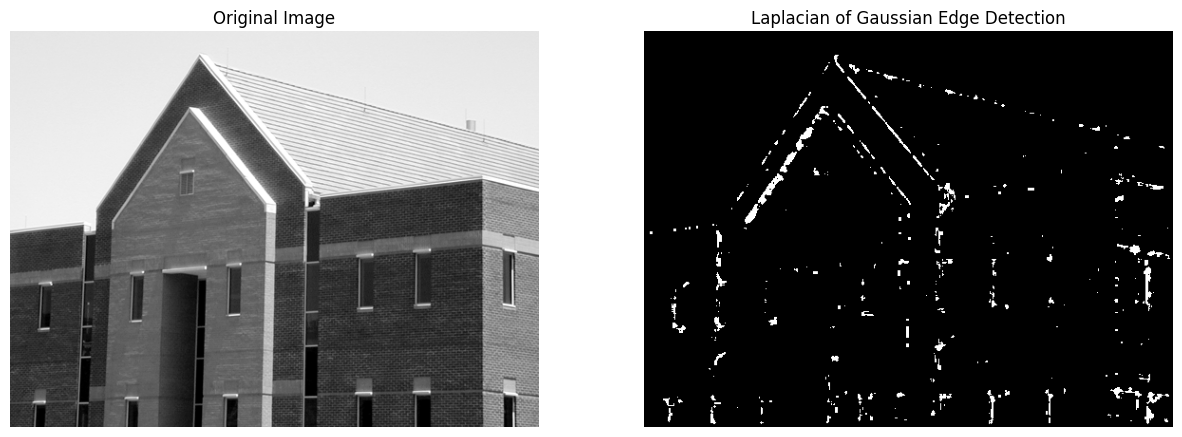

In [78]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import requests

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/09_Canny/'

fileNames = ["dom.png"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)

def crossing(img, threshold, kernel_size=5):
    size = 3
    rows, cols = img.shape
    table = np.zeros((rows, cols), dtype=np.float32)
    radius = size //2

    for row in range(1 + radius, rows - 1 - radius):
        for col in range(1 + radius, cols - 1 - radius):
            patch = img[row - radius: row + radius + 1, col - radius: col + radius + 1]

            val_min = np.min(patch)
            val_max = np.max(patch)

            if val_max > 0 and val_min < 0:
                pixel = img[row, col]

                if pixel > 0:
                    pixel += abs(val_min)
                elif pixel < 0:
                    pixel = abs(pixel) + val_max
            
                table[row, col] = pixel
    
    normalized = cv2.normalize(table, None, 0, 255, cv2.NORM_MINMAX)
    _, binary = cv2.threshold(normalized, threshold, 255, cv2.THRESH_BINARY)
    
    binary = binary.astype(np.uint8)
    result = cv2.medianBlur(binary, kernel_size)

    return result                


def Laplasjan_of_Gaussian(img, size, sigma, threshold=10):
    blurred = cv2.GaussianBlur(img, (size, size), sigma)
    laplacian = cv2.Laplacian(blurred, cv2.CV_32F)
    
    LoG = crossing(laplacian, threshold, kernel_size=5)
    return LoG

img = cv2.imread('dom.png', cv2.IMREAD_GRAYSCALE)
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(Laplasjan_of_Gaussian(img, size=9, sigma=1.9, threshold=49), cmap='gray')
axes[1].set_title('Laplacian of Gaussian Edge Detection')
axes[1].axis('off')
plt.show()

## Algorytm Canny'ego

> Algorytm Canny'ego to często wykorzystywana metoda detekcji krawędzi.
> Zaproponowana została w 1986r. przez Johna F. Cannego.
> Przy jego projektowaniu założono trzy cele:
> - niska liczba błędów - algorytm powinien znajdywać wszystkie krawędzie oraz generować jak najmniej fałszywych detekcji,
> - punkty krawędziowe powinny być poprawnie lokalizowane - wykryte punkty powinny być jak najbardziej zbliżone do rzeczywistych,
> - krawędzie o szerokości 1 piksela - algorytm powinien zwrócić jeden punkt dla każdej rzeczywistej krawędzi.

Zaimplementuj algorytm detekcji krawędziCanny'ego:
1. W pierwszym kroku obraz przefiltruj dwuwymiarowym filtrem Gaussa.
2. Następnie oblicz gradient pionowy i poziomy ($g_x $ i $g_y$).
Jedną z metod jest filtracja Sobela.
3. Dalej oblicz amplitudę:
$M(x,y)  = \sqrt{g_x^2+g_y^2}$ oraz kąt:
$\alpha(x,y) = arctan(\frac{g_y}{g_x})$.
Do obliczenia kąta wykorzystaj funkcję `np.arctan2(x1, x2)`.
Wynik jest w radianach.
4. W kolejnym etapie wykonaj kwantyzację kątów gradientu.
Kąty od $-180^\circ$ do $180^\circ$ można podzielić na 8 przedziałów:
[$-22.5^\circ, 22.5^\circ$], [$22.5^\circ, 67.5^\circ$],
[$67.5^\circ, 112.5^\circ$], [$112.5^\circ, 157.5^\circ$],
[$157.5^\circ, -157.5^\circ$], [$-157.5^\circ, -112.5^\circ$],
[$-112.5^\circ, -67.5^\circ$], [$-67.5^\circ, -22.5^\circ$].
Przy czym należy rozpatrywać tylko 4 kierunki:
    - pionowy ($d_1$),
    - poziomy ($d_2$),
    - skośny lewy ($d_3$),
    - skośny prawy ($d_4$).
5. Dalej przeprowadź eliminację pikseli, które nie mają wartości maksymalnej (ang. *nonmaximal suppresion*).
Celem tej operacji jest redukcja szerokości krawędzi do rozmiaru 1 piksela.
Algorytm przebiega następująco.
W rozpatrywanym otoczeniu o rozmiarze $3 \times 3$:
    - określ do którego przedziału należy kierunek gradientu piksela centralnego ($d_1, d_2, d_3, d_4$).
    - przeanalizuje sąsiadów leżących na tym kierunku.
Jeśli choć jeden z nich ma amplitudę większą niż piksel centralny, to należy uznać, że nie jest lokalnym maksimum i do wyniku przypisać $g_N(x,y) = 0$.
W przeciwnym przypadku $g_N(x,y) = M(x,y)$.
Przez $g_N$ rozumiemy obraz detekcji lokalnych maksimów.
Zaimplementuj funkcję `nonmax`.
Pierwszym argementem jest macierz kierunków (po kwantyzacji).
Drugim argumentem jest macierz amplitudy.
6. Ostatnią operacją jest binaryzacja obrazu $g_N$.
Stosuje się tutaj tzw. binaryzację z histerezą.
Wykorzystuje się w niej dwa progi: $T_L$ i $T_H$, przy czym $T_L < T_H$.
Canny zaproponował, aby stosunek progu wyższego do niższego był jak 3 lub 2 do 1.
Rezultaty binaryzacji można opisać jako:<br>
$g_{NH}(x,y) = g_N(x,y) \geq TH $<br>
$g_{NL}(x,y) = TH > g_N(x,y) \geq TL $<br>
Można powiedzieć, że na obrazie $g_{NH}$ są "pewne" krawędzie.
Natomiast na $g_{NL}$ "potencjalne".
Często krawędzie "pewne" nie są ciągłe.
Dlatego wykorzystuje się obraz $g_{NL}$ w następującej procedurze:
    - Stwórz stos zawierający wszystkie piksele zaznaczone na obrazie $g_{NH}$.
W tym celu wykorzystaj listę współrzędnych `[row, col]`.
Do pobrania elementu z początku służy metoda `list.pop()`.
Do dodania elementu na koniec listy służy metoda `list.append(new)`.
    - Stwórz obraz, który będzie zawierał informację czy dany piksel został już odwiedzony.
    - Stwórz obraz, któy zawierać będzie wynikowe krawędzie.
Jej rozmiar jest równy rozmiarowi obrazu.
    - Wykonaj pętlę, która będzie pobierać elementy z listy, dopóki ta nie będzie pusta.
W tym celu najlepiej sprawdzi się pętla `while`.
    - W każdej iteracji pobierz element ze stosu.
    - Sprawdź czy dany element został już odwiedzony.
    - Jeśli nie został, to:
        - Oznacz go jako odwiedzony,
        - Oznacz piksel jako krawędź w wyniku,
        - Sprawdź otoczenie piksela w obrazie $g_{NL}$,
        - Dodaj do stosu współrzędne otoczenia, które zawierają krawędź (potencjalną).
        Można to wykoanać np. pętlą po stworzonym otoczeniu.
7. Wyświetl obraz oryginalny, obraz $g_{NH}$ oraz obraz wynikowy.

Pomocnicze obrazy $g_{NH}$ i $g_{NL}$ zostały wprowadzone dla uproszczenia opisu.
Algorytm można zaimplementować wbardziej "zwarty" sposób.

Na podstawie powyższego opisu zaimplementuj algorytm Cannego.

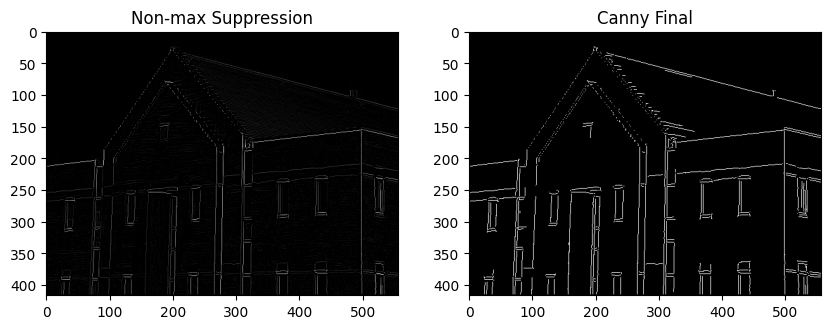

In [79]:
def nonmax(angle, amplitude):
    rows, cols = amplitude.shape
    g_N = np.zeros((rows, cols), dtype=np.float32)
    
    for i in range(1, rows-1):
        for j in range(1, cols-1):
            a = angle[i, j]
            
            # poziomy
            if (0 <= a < 22.5) or (157.5 <= a <= 180):
                q = amplitude[i, j+1]
                r = amplitude[i, j-1]
            # skośny prawy
            elif (22.5 <= a < 67.5):
                q = amplitude[i+1, j-1]
                r = amplitude[i-1, j+1]
            # pionowy
            elif (67.5 <= a < 112.5):
                q = amplitude[i+1, j]
                r = amplitude[i-1, j]
            # skośny lewy
            elif (112.5 <= a < 157.5):
                q = amplitude[i-1, j-1]
                r = amplitude[i+1, j+1]

            if (amplitude[i, j] >= q) and (amplitude[i, j] >= r):
                g_N[i, j] = amplitude[i, j]
            else:
                g_N[i, j] = 0
                
    return g_N

def Canny(img, size, sigma, threshold_low=30, threshold_high=90):
    rows, cols = img.shape
    blurred = cv2.GaussianBlur(img, (size, size), sigma)
    
    gx = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)
    
    amplitude = np.sqrt(gx**2 + gy**2) # jak mocno zmienia się jasność
    angle = np.arctan2(gy, gx) * 180 / np.pi # kierunek zmiany jasności w stopniach
    angle[angle < 0] += 180

    g_N = nonmax(angle, amplitude)

    g_NH = g_N >= threshold_high
    g_NL = (g_N >= threshold_low) & (g_N < threshold_high)

    final_edges = np.zeros(g_N.shape, dtype=np.uint8)

    strong_pixels = np.argwhere(g_NH)
    stack = [list(pt) for pt in strong_pixels]

    visited = np.zeros(g_N.shape, dtype=bool)

    for r, c in stack:
        visited[r, c] = True
        final_edges[r, c] = 255

    while len(stack) > 0:
        curr_r, curr_c = stack.pop()
        
        for k in range(-1, 2):
            for l in range(-1, 2):
                neighbor_r = curr_r + k
                neighbor_c = curr_c + l
                
                if 0 <= neighbor_r < rows and 0 <= neighbor_c < cols:
                    if not visited[neighbor_r, neighbor_c] and g_NL[neighbor_r, neighbor_c]:
                        visited[neighbor_r, neighbor_c] = True
                        final_edges[neighbor_r, neighbor_c] = 255
                        stack.append([neighbor_r, neighbor_c])

    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(g_N, cmap='gray'), plt.title('Non-max Suppression')
    plt.subplot(122), plt.imshow(final_edges, cmap='gray'), plt.title('Canny Final')
    plt.show()

Canny(img, size=5, sigma=1.4, threshold_low=30, threshold_high=90)

## Algorytm Canny'ego - OpenCV

1. Wykonaj dektekcję krawędzi metodą Canny'ego wykorzystując funkcję `cv2.Canny`.
    - Pierwszym argumentem funkcji jest obraz wejściowy.
    - Drugim argumentem jest mniejszy próg.
    - Trzecim argumentem jest większy próg.
    - Czwarty argument to tablica, do której wpisany zostanie wynik.
    Można zwrócić go przez wartość i podać wartość `None`.
    - Piąty argument to rozmiar operatora Sobela (w naszym przypadku 3).
    - Szósty argument to rodzaj używanej normy.
    0 oznacza normę $L_1$, 1 oznacza normę $L_2$. Użyj $L_2$.
2. Wynik wyświetl i porównaj z własną implementacją.

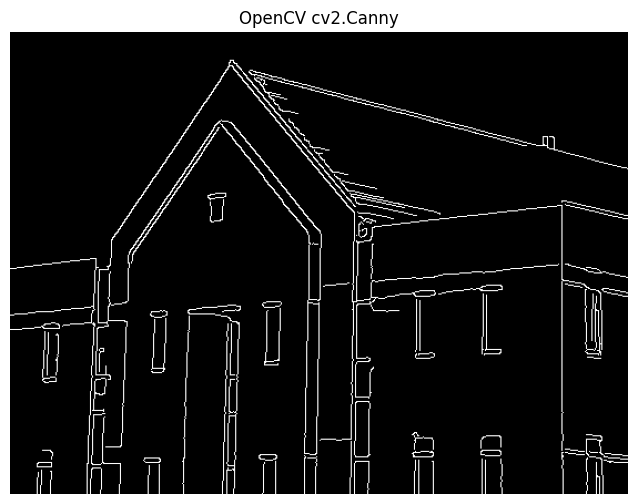

In [90]:
size = 5
sigma = 1.4

blurred = cv2.GaussianBlur(img, (size, size), sigma)

thr_lower = 30
thr_upper = 90
sobel_size = 3

canny_opencv = cv2.Canny(blurred, thr_lower, thr_upper, None, apertureSize=sobel_size, L2gradient=True)

plt.figure(figsize=(12, 6))
plt.imshow(canny_opencv, cmap='gray')
plt.title('OpenCV cv2.Canny')
plt.axis('off')

plt.show()